# Gene-filter threshold `N` vs. spectral structure

**Question.** The gene filter exists to restore a spectral gap, so that a rank-`d`
subspace is *determined* rather than arbitrary (paper Q4). Picking `N` by gene
count is picking by eye. This measures the thing the filter is meant to fix.

Two quantities, on **main rows only** (one true observation per `(perturbation,
context)`), across the 12 built contexts:

- **Participation ratio** `PR = (sum lambda_i)^2 / sum lambda_i^2` -- the effective rank of
  the covariance. `PR` far above `d` means no rank-`d` subspace stands out.
  Falling toward `d = 24` as `N` rises is the filter working.
- **Top-24 captured energy** -- fraction of centred energy inside the best rank-24
  subspace. Rising with `N` means the retained genes are more coherently structured.

Criterion: `|logFC| > ln(1.2) = 0.18232` (a 20% shift), counted over `(p,c)` pairs.

In [1]:
import numpy as np, pandas as pd, sys, time
from pathlib import Path
from scipy.sparse.linalg import eigsh
sys.path.insert(0, str(Path.cwd().parents[1] / "src"))
from module_finder.de import load_matrices

D = 24                                   # the rank we actually fit
N_GRID = [50, 100, 150, 200, 300, 500]
GENE_LIST = "/large_storage/ctc/beraslan/ModuleFinder/gene_lists/affected_N100_thr0.18232.tsv"

counts = pd.read_csv(GENE_LIST, sep="\t", comment="#").set_index("gene")["n_affected"]
X, meta = load_matrices(variant="main")
genes = np.asarray(X.columns)
Xv = X.to_numpy(dtype=np.float32); del X
counts = counts.reindex(genes).fillna(0).to_numpy()
print(f"main rows: {Xv.shape[0]:,} x {Xv.shape[1]:,} genes, {meta.context.nunique()} contexts")

  AR-A014418: 2,060 rows


  AZD4573: 2,039 rows


  Bisindolylmaleimide-I: 2,049 rows


  CHIR-98014: 2,026 rows


  DG-172: 2,079 rows


...

  LDN-193189: 2,063 rows


  LY2090314: 2,009 rows


  Lexibulin: 2,078 rows


  Stattic: 2,067 rows


main rows: 24,573 x 18,154 genes, 12 contexts


In [2]:
def spectrum_stats(Xsub, k=D):
    """Exact participation ratio + top-k captured energy, without a full SVD.

    With C = Xc^T Xc, the eigenvalues of C are the lambda_i, so
        sum lambda_i   = trace(C)        and     sum lambda_i^2 = ||C||_F^2 ,
    both exact and far cheaper than decomposing a 24k x G matrix."""
    Xc = Xsub - Xsub.mean(0, keepdims=True)
    Cm = (Xc.T @ Xc).astype(np.float64)
    tr = np.trace(Cm)
    pr = tr**2 / (Cm**2).sum()
    top = eigsh(Cm, k=k, which="LA", return_eigenvectors=False)
    return pr, float(top.sum() / tr)

rows = []
for N in N_GRID:
    keep = counts >= N
    t0 = time.time()
    pr, cap = spectrum_stats(Xv[:, keep])
    rows.append({"N": N, "genes": int(keep.sum()),
                 "participation_ratio": pr, "top24_energy": cap})
    print(f"  N={N:<4} genes={keep.sum():>6,}  PR={pr:7.2f}  top-{D} energy={cap:.3%}"
          f"   ({time.time()-t0:.0f}s)")
res = pd.DataFrame(rows)

  N=50   genes= 7,073  PR=   7.47  top-24 energy=56.906%   (3s)


  N=100  genes= 5,169  PR=   6.74  top-24 energy=59.013%   (2s)


  N=150  genes= 4,039  PR=   6.15  top-24 energy=60.923%   (2s)


  N=200  genes= 3,307  PR=   5.68  top-24 energy=62.571%   (2s)


  N=300  genes= 2,363  PR=   4.97  top-24 energy=65.363%   (2s)


  N=500  genes= 1,380  PR=   4.06  top-24 energy=69.866%   (2s)


In [3]:
# Table view -- always ships alongside the figure
res.assign(**{"top24_energy": (res.top24_energy*100).round(2),
              "participation_ratio": res.participation_ratio.round(1),
              "PR / d": (res.participation_ratio/D).round(1)})

,N,genes,participation_ratio,top24_energy,PR / d
0,50,7073,7.5,56.91,0.3
1,100,5169,6.7,59.01,0.3
2,150,4039,6.1,60.92,0.3
3,200,3307,5.7,62.57,0.2
4,300,2363,5.0,65.36,0.2
5,500,1380,4.1,69.87,0.2


/tmp/ipykernel_673932/2101932466.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0,0,1,0.93])


rewrote /large_storage/ctc/beraslan/ModuleFinder/gene_lists/gene_filter_N_spectrum.png


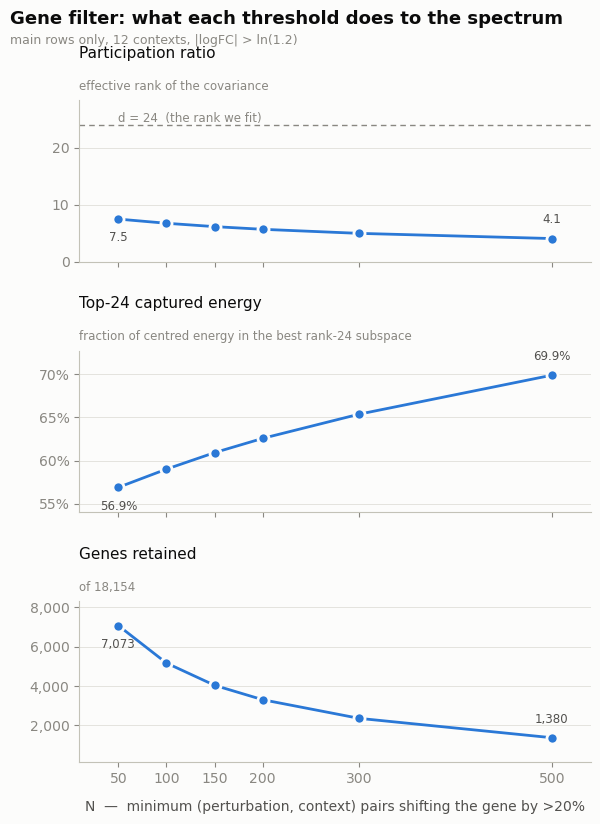

In [4]:
import matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path
out = Path("/large_storage/ctc/beraslan/ModuleFinder/gene_lists/gene_filter_N_spectrum.png")
res.to_csv(out.with_suffix('.csv'), index=False)

SURFACE,INK,INK2,MUTED,AXIS="#fcfcfb","#0b0b0b","#52514e","#898781","#c3c2b7"
SERIES="#2a78d6"
mpl.rcParams.update({"figure.facecolor":SURFACE,"axes.facecolor":SURFACE,
    "savefig.facecolor":SURFACE,"font.size":10,"text.color":INK,
    "axes.labelcolor":INK2,"axes.edgecolor":AXIS,"xtick.color":MUTED,
    "ytick.color":MUTED,"axes.spines.top":False,"axes.spines.right":False})

fig,axes=plt.subplots(3,1,figsize=(6.6,8.6),sharex=True,
                      gridspec_kw={"hspace":0.55})
panels=[("participation_ratio","Participation ratio","effective rank of the covariance"),
        ("top24_energy",f"Top-{D} captured energy",
         f"fraction of centred energy in the best rank-{D} subspace"),
        ("genes","Genes retained","of 18,154")]
for ax,(col,title,sub) in zip(axes,panels):
    y=res[col]*100 if col=="top24_energy" else res[col]
    ax.plot(res.N,y,color=SERIES,lw=2,marker="o",ms=8,mec=SURFACE,mew=2,
            zorder=3,clip_on=False)
    ax.set_title(f"{title}\n", loc="left", fontsize=11, color=INK,
                 pad=18, fontweight="medium")
    ax.text(0,1.045,sub,transform=ax.transAxes,fontsize=8.5,color=MUTED,va="bottom")
    ax.grid(axis="y",color=AXIS,lw=0.6,alpha=0.5,zorder=0); ax.set_axisbelow(True)
    ax.margins(x=0.09,y=0.22)

# d = 24 reference, label placed INSIDE the axes
axes[0].set_ylim(0, D*1.18)
axes[0].axhline(D,color=MUTED,lw=1,ls=(0,(4,3)),zorder=1)
axes[0].text(res.N.min(), D, f"d = {D}  (the rank we fit)", va="bottom", ha="left",
             fontsize=8.5, color=MUTED)
axes[1].yaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
axes[2].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v,_:f"{v:,.0f}"))

# endpoint labels only; first one below the mark so it clears the subtitle
for ax,col in zip(axes,[p[0] for p in panels]):
    for i,dy in ((0,-16),(len(res)-1,11)):
        v=res[col].iloc[i]; yy=v*100 if col=="top24_energy" else v
        lab=f"{v*100:.1f}%" if col=="top24_energy" else (f"{v:,.0f}" if col=="genes" else f"{v:.1f}")
        ax.annotate(lab,(res.N.iloc[i],yy),textcoords="offset points",
                    xytext=(0,dy),ha="center",fontsize=8.5,color=INK2)

axes[-1].set_xlabel("N  —  minimum (perturbation, context) pairs shifting the gene by >20%",
                    labelpad=10)
axes[-1].set_xticks(res.N)
fig.tight_layout(rect=[0,0,1,0.93])
fig.text(0.02,0.985,"Gene filter: what each threshold does to the spectrum",
         ha="left",va="top",fontsize=13,color=INK,fontweight="semibold")
fig.text(0.02,0.957,"main rows only, 12 contexts, |logFC| > ln(1.2)",
         ha="left",va="top",fontsize=9,color=MUTED)
fig.savefig(out,dpi=200,bbox_inches="tight"); print("rewrote",out)
plt.show()


## Reading it

**Participation ratio** is the one that decides. The filter is justified only if
`PR` falls toward `d = 24` as `N` rises — that is the spectral gap reappearing.
If it plateaus, higher `N` is discarding genes for nothing.

**Top-24 captured energy** should rise with `N` for the same reason: fewer, more
responsive genes mean the leading subspace explains more of what is left.

**Caveat.** 12 of 16 contexts. Counts can only rise as contexts are added, so
every `N` here will retain more genes at 16 — the *shape* of these curves should
hold, but the gene numbers will shift.